# Minimum Wage and State Poverty Rates (2023)

** Research Question:** Do states wwith minimum wages above the federal minimum ($7.25/hr) have lower poverty rates than states that default to the federal minimum?


## Hypothesis

**Null Hypothesis (H_0 ): ** There is no difference in mean poverty rates between states with minimum wages above the federal minimum and states at the federal minimum. Any observed difference is due to chance.

** Alternative Hypothesis (H_1)** States with minimum wages above the federal minimum ($7.25/hr) have lower mean poverty rates than states at the federal minimum.


## Step 1: Importing Libraries



In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



## Step 2: Loading and Inspecting the raw Data

**Data Sources:**
- `min_wage_2023` — U.S. Department of Labor
- `unemployment_rate_2023` — U.S. Bureau of Labor Statistics
- `cost_of_living_index_2023` — Missouri Economic Research & Information Center (MERIC)
- `median_household_income_2023`, `population_2023`, `num_below_poverty_line_2023` — U.S. Census Bureau ACS 2023

In [14]:
# Loading the dataset
df=pd.read_csv('state_wages_poverty_Dataset.csv')
print(df.head())







        state state_abbr region min_wage_2023 unemployment_rate_2023  \
0     Alabama         AL  South         $7.25                   2.5%   
1      Alaska         AK   West        $13.75                    4.2   
2     Arizona         AZ   West        $13.85                   3.9%   
3    Arkansas         AR  South        $11.00                   3.3%   
4  California         CA   West        $15.50                   4.8%   

   cost_of_living_index_2023 median_household_income_2023  population_2023  \
0                       89.3                       $58241          5108468   
1                      124.1                       $82016           733583   
2                      103.7                       $72581          7431344   
3                       88.8                       $56335          3045637   
4                      142.2                       $84097         39029342   

   num_below_poverty_line_2023             notes_min_wage  
0                       859824  No sta

In [15]:
# Check data types:
print("Data types:")
print(df.dtypes) 

Data types:
state                               str
state_abbr                          str
region                              str
min_wage_2023                       str
unemployment_rate_2023              str
cost_of_living_index_2023       float64
median_household_income_2023        str
population_2023                   int64
num_below_poverty_line_2023       int64
notes_min_wage                      str
dtype: object


In [16]:
#Check missing values
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
state                            0
state_abbr                       0
region                           0
min_wage_2023                    0
unemployment_rate_2023           0
cost_of_living_index_2023        0
median_household_income_2023     0
population_2023                  0
num_below_poverty_line_2023      0
notes_min_wage                  37
dtype: int64


In [17]:
# Check for duplicates:
print(f'\nDuplicate rows: {df.duplicated().sum()}')


Duplicate rows: 1


In [18]:
# Show the duplicate:
print("\nDuplicated row:")
print(df[df.duplicated(keep=False)][['state', 'min_wage_2023', 'num_below_poverty_line_2023']])


Duplicated row:
                   state min_wage_2023  num_below_poverty_line_2023
50  District of Columbia        $17.00                       114206
51  District of Columbia        $17.00                       114206


## Step 3: Cleaning the data:

### Issues Found in Raw Data

| Issue | Column | Fix |
|---|---|---|
| Dollar signs (`$`) | `min_wage_2023`, `median_household_income_2023` | Strip `$` and convert to float |
| Percent signs (`%`) | `unemployment_rate_2023` | Strip `%` and convert to float |
| Duplicate row | District of Columbia appears twice | Drop duplicates |
| Below federal floor | Georgia and Wyoming at `$5.15` | Clip to `$7.25` |
| Irrelevant column | `notes_min_wage` — 37 missing values | Drop column |


In [19]:
data=df.copy()
data=data.drop_duplicates()
print(f'\nDuplicate rows after dropping: {data.duplicated().sum()}')



Duplicate rows after dropping: 0


In [20]:
# Strip % signs and convert to float
data['unemployment_rate_2023'] = (
    data['unemployment_rate_2023']
    .astype(str)
    .str.replace('%', '', regex=False)
    .str.strip()
    .astype(float)
)
print(data['unemployment_rate_2023'].head(10).tolist())
print("Data type:", data['unemployment_rate_2023'].dtype)

[2.5, 4.2, 3.9, 3.3, 4.8, 3.2, 3.8, 4.0, 2.9, 3.2]
Data type: float64


In [21]:
# Strip $ signs and commas, convert to float
data['median_household_income_2023'] = (
    data['median_household_income_2023']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .astype(float)
)
print(data['median_household_income_2023'].head(10).tolist())
print("Data type:", data['median_household_income_2023'].dtype)

[58241.0, 82016.0, 72581.0, 56335.0, 84097.0, 87598.0, 90213.0, 79325.0, 67688.0, 71355.0]
Data type: float64


In [22]:
data.head()

,state,state_abbr,region,min_wage_2023,unemployment_rate_2023,cost_of_living_index_2023,median_household_income_2023,population_2023,num_below_poverty_line_2023,notes_min_wage
0,Alabama,AL,South,$7.25,2.5,89.3,58241.0,5108468,859824,No state minimum wage law
1,Alaska,AK,West,$13.75,4.2,124.1,82016.0,733583,72724,NaN
2,Arizona,AZ,West,$13.85,3.9,103.7,72581.0,7431344,976737,NaN
3,Arkansas,AR,South,$11.00,3.3,88.8,56335.0,3045637,524491,NaN
4,California,CA,West,$15.50,4.8,142.2,84097.0,39029342,4993567,NaN


In [23]:
# Fixing a variable for the Federal minimum wage in 2023: $7.25/hr
F_min_wage = 7.25
# Replacing any state minimum wage below the federal floor with the federal minimum wage:
data['effective_min_wage'] = data['min_wage_2023'].clip(lower=F_min_wage)
# Showing which states got adjusted:
adjusted = data[data['min_wage_2023'] < F_min_wage][['state', 'min_wage_2023', 'effective_min_wage']]
print("States adjusted to federal floor:")
print(adjusted)

TypeError: '>=' not supported between instances of 'str' and 'float'

In [ ]:
# Dropping the notes column:
data = data.drop(columns=['notes_min_wage'])

## Step 4: Deriving New Columns for our analysis 


In [ ]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   state                         51 non-null     str    
 1   state_abbr                    51 non-null     str    
 2   region                        51 non-null     str    
 3   min_wage_2023                 51 non-null     float64
 4   unemployment_rate_2023        51 non-null     float64
 5   cost_of_living_index_2023     51 non-null     float64
 6   median_household_income_2023  51 non-null     float64
 7   population_2023               51 non-null     int64  
 8   num_below_poverty_line_2023   51 non-null     int64  
 9   effective_min_wage            51 non-null     float64
dtypes: float64(5), int64(2), str(3)
memory usage: 4.1 KB


In [ ]:
data['median_household_income_2023']=data['median_household_income_2023'].astype(float)

In [ ]:
# Deriving poverty rate:
data['poverty_rate_2023'] = (data['num_below_poverty_line_2023'] / data['population_2023']) * 100
# Derive real_min_wage
data['real_min_wage'] = data['effective_min_wage'] / (data['cost_of_living_index_2023'] / 100)
# Create binary group column:
data['above_federal'] = (data['effective_min_wage'] > F_min_wage).astype(int)
# Group labelling:
data['group_label'] = data['above_federal'].map({
    0: 'At Federal Min ($7.25)', 
    1: 'Above Federal Min'
})

print(data[['state', 'poverty_rate_2023', 'min_wage_2023', 'above_federal', 'group_label']].head(10))


         state  poverty_rate_2023  min_wage_2023  above_federal  \
0      Alabama          16.831347           7.25              0   
1       Alaska           9.913534          13.75              1   
2      Arizona          13.143477          13.85              1   
3     Arkansas          17.221061          11.00              1   
4   California          12.794392          15.50              1   
5     Colorado           9.600002          13.65              1   
6  Connecticut          10.468024          15.00              1   
7     Delaware          11.390289          11.75              1   
8      Florida          13.833629          12.00              1   
9      Georgia          15.337598           5.15              0   

              group_label  
0  At Federal Min ($7.25)  
1       Above Federal Min  
2       Above Federal Min  
3       Above Federal Min  
4       Above Federal Min  
5       Above Federal Min  
6       Above Federal Min  
7       Above Federal Min  
8       Ab

## Step 5: Exlporatory Data Analysis:
(Exploring the Data Visually)

In [ ]:
summary = data.groupby('group_label')['poverty_rate_2023'].agg(
    count='count',
    mean='mean',
    median='median',
    std='std',
    min='min',
    max='max'
).round(2)

print("Summary Statistics by Group:")
print(summary)

Summary Statistics by Group:
                        count   mean  median   std  min    max
group_label                                                   
Above Federal Min          31  12.25   11.69  2.67  9.0  18.63
At Federal Min ($7.25)     20  13.40   13.56  3.53  7.5  20.30


**observations:**
- States above the federal minimum have on average 1.15 percentage points lower poverty — this is our observed difference
- The "at federal min" group has a higher standard deviation (3.45 vs 2.62) — poverty rates are more spread out in those states
- The minimum poverty rate in the "at federal min" group is 7.5% — showing not all low-wage states are poor

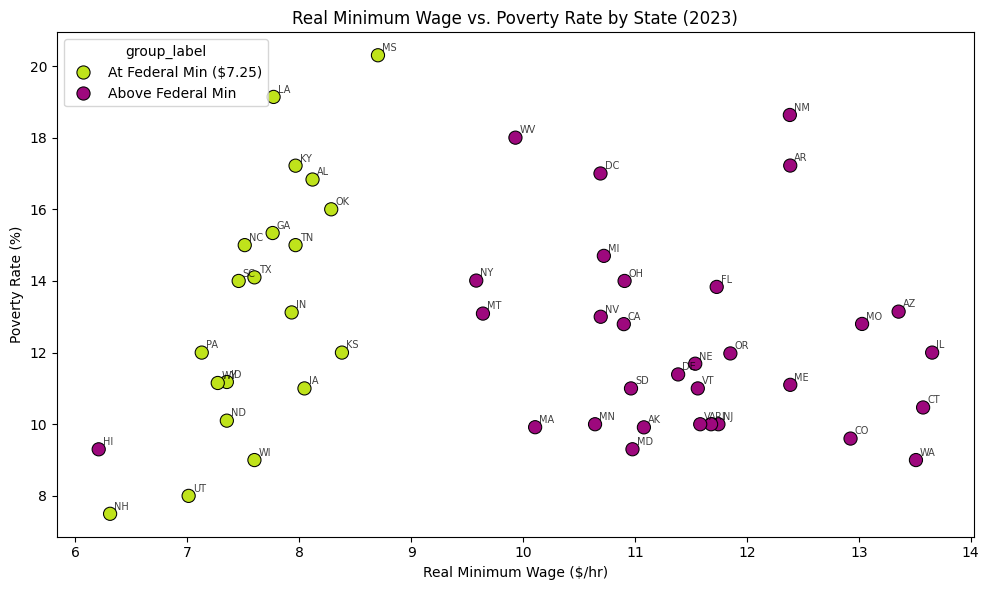

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x='real_min_wage',
    y='poverty_rate_2023',
    hue='group_label',
    palette=['#bfe31b', '#9d087d'],
    s=90,
    edgecolor='k',
    ax=ax
)
for _, row in data.iterrows():
    ax.annotate(row['state_abbr'],
                (row['real_min_wage'], row['poverty_rate_2023']),
                fontsize=7, alpha=0.75,
                xytext=(3, 3), textcoords='offset points')
    
ax.set_title('Real Minimum Wage vs. Poverty Rate by State (2023)')
ax.set_xlabel('Real Minimum Wage ($/hr)')
ax.set_ylabel('Poverty Rate (%)')
plt.tight_layout()
plt.show()

**Scatter plot interpretation:**
- There is a slight downward trend — as real minimum wage increases, poverty rate tends to decrease
- Mississippi (MS) and Louisiana (LA) stand out as high-poverty, low-wage states
- New Hampshire (NH) is an outlier — at federal minimum but low poverty due to overall state wealth
- The relationship is not perfectly linear — other factors clearly influence poverty rates.

In [ ]:
data.columns


Index(['state', 'state_abbr', 'region', 'min_wage_2023',
       'unemployment_rate_2023', 'cost_of_living_index_2023',
       'median_household_income_2023', 'population_2023',
       'num_below_poverty_line_2023', 'effective_min_wage',
       'poverty_rate_2023', 'real_min_wage', 'above_federal', 'group_label'],
      dtype='str')

## Step 6: Permutation Test:

A permutation test answers the question: *"If there were truly no difference between the two groups, how often would we see a difference as large as the one we observed?"*

**Idea**
1. Compute the observed difference in mean poverty rates between the two groups
2. Shuffle (permute) the group labels randomly 10,000 times
3. Compute the mean difference for each shuffle
4. Count how often the shuffled difference is as large or larger than the observed difference
5. That proportion is the **p-value**

**Test statistic:** Difference in mean poverty rates (at federal min − above federal min)

In [ ]:
group_at    = data[data['above_federal'] == 0]['poverty_rate_2023'].values
group_above = data[data['above_federal'] == 1]['poverty_rate_2023'].values

observed_diff = group_at.mean() - group_above.mean()

print(f"Mean poverty (at federal min):    {group_at.mean():.2f}%")
print(f"Mean poverty (above federal min): {group_above.mean():.2f}%")
print(f"Observed difference:              {observed_diff:.2f} percentage points")

Mean poverty (at federal min):    13.40%
Mean poverty (above federal min): 12.25%
Observed difference:              1.14 percentage points


In [ ]:
N_PERMUTATIONS = 10_000
all_poverty = data['poverty_rate_2023'].values
n_at = len(group_at)

perm_diffs = np.array([
    np.random.permutation(all_poverty)[:n_at].mean() -
    np.random.permutation(all_poverty)[n_at:].mean()
    for _ in range(N_PERMUTATIONS)
])

p_value = (perm_diffs >= observed_diff).mean()
print(f"P-value (one-tailed): {p_value:.4f}")

if p_value < 0.05:
    print("Result: SIGNIFICANT — reject H0")
else:
    print("Result: NOT significant — fail to reject H0")

P-value (one-tailed): 0.0365
Result: SIGNIFICANT — reject H0


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(perm_diffs, bins=50, color="#62cfe3", alpha=0.7, edgecolor='white')
ax.axvline(observed_diff, color="#4d1be3", linewidth=2,
           label=f'Observed diff = {observed_diff:.2f}pp')
ax.set_title('Permutation Test: Null Distribution (10,000 permutations)')
ax.set_xlabel('Difference in Mean Poverty Rate (at − above, %)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

### Permutation Test Results

- **Observed difference:** 1.14 percentage points
- **P-value:** 0.0365
- **Decision:** Reject H0 

**Interpretation:**
The blue line sits in the right tail of the null distribution. Only 3.65% of random permutations produced a difference as large as 1.14 percentage points. Since this is below our significance threshold of 0.05, we reject the null hypothesis — the observed difference is unlikely to be due to chance alone.


## Step 7: Bootstrap Confidence Intervals

1. **Mean difference** — the CLT may apply here since we are working with means, but bootstrap provides a model-free check
2. **Median difference** — the CLT does **NOT** apply to the median because:
   - The CLT guarantees normality for **means**, not medians
   - With only ~20 states per group, the sample size is small
   - Poverty rate distributions are skewed — not symmetric
   - Therefore bootstrapping is the only appropriate method here

In [ ]:
N_BOOTSTRAP = 10_000
boot_mean_diffs, boot_median_diffs = [], []

for _ in range(N_BOOTSTRAP):
    s_at    = np.random.choice(group_at,    size=len(group_at),    replace=True)
    s_above = np.random.choice(group_above, size=len(group_above), replace=True)
    
    boot_mean_diffs.append(s_at.mean()       - s_above.mean())
    boot_median_diffs.append(np.median(s_at) - np.median(s_above))

boot_mean_diffs   = np.array(boot_mean_diffs)
boot_median_diffs = np.array(boot_median_diffs)

ci_mean   = np.percentile(boot_mean_diffs,   [2.5, 97.5])
ci_median = np.percentile(boot_median_diffs, [2.5, 97.5])

print(f"95% CI (mean diff):   [{ci_mean[0]:.2f}, {ci_mean[1]:.2f}] pp")
print(f"95% CI (median diff): [{ci_median[0]:.2f}, {ci_median[1]:.2f}] pp")

95% CI (mean diff):   [-0.61, 2.90] pp
95% CI (median diff): [-1.00, 4.05] pp


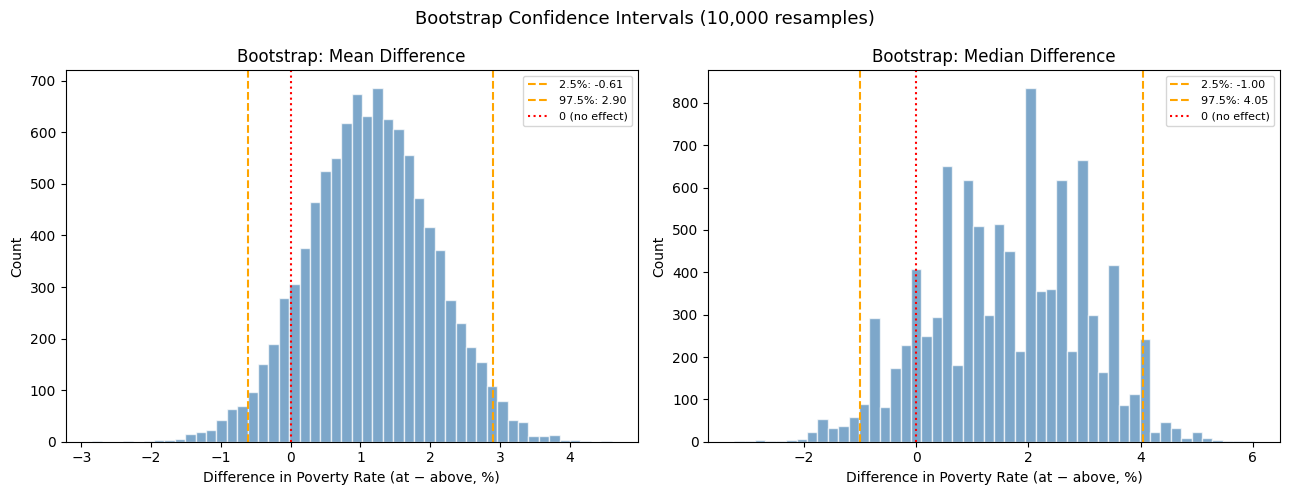

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, diffs, ci, title in zip(
    axes,
    [boot_mean_diffs, boot_median_diffs],
    [ci_mean, ci_median],
    ['Mean Difference', 'Median Difference']
):
    ax.hist(diffs, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
    ax.axvline(ci[0], color='orange', linestyle='--', 
               linewidth=1.5, label=f'2.5%: {ci[0]:.2f}')
    ax.axvline(ci[1], color='orange', linestyle='--', 
               linewidth=1.5, label=f'97.5%: {ci[1]:.2f}')
    ax.axvline(0, color='red', linewidth=1.5, 
               linestyle=':', label='0 (no effect)')
    ax.set_title(f'Bootstrap: {title}')
    ax.set_xlabel('Difference in Poverty Rate (at − above, %)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.suptitle('Bootstrap Confidence Intervals (10,000 resamples)', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
print('='*55)
print('RESULTS SUMMARY')
print('='*55)
print(f"States at federal min:         {len(group_at)}")
print(f"States above federal min:      {len(group_above)}")
print(f"Mean poverty (at federal min): {group_at.mean():.2f}%")
print(f"Mean poverty (above fed min):  {group_above.mean():.2f}%")
print(f"Observed difference:           {observed_diff:.2f} pp")
print(f"P-value:                       {p_value:.4f}")
print(f"95% CI (mean diff):   [{ci_mean[0]:.2f}, {ci_mean[1]:.2f}]")
print(f"95% CI (median diff): [{ci_median[0]:.2f}, {ci_median[1]:.2f}]")

if ci_median[0] > 0:
    print("\nMedian CI excludes 0 — supports alternative hypothesis")
else:
    print("\nMedian CI includes 0 — direction uncertain")

RESULTS SUMMARY
States at federal min:         20
States above federal min:      31
Mean poverty (at federal min): 13.40%
Mean poverty (above fed min):  12.25%
Observed difference:           1.14 pp
P-value:                       0.0365
95% CI (mean diff):   [-0.61, 2.90]
95% CI (median diff): [-1.00, 4.05]

Median CI includes 0 — direction uncertain


| Metric | 95% Confidence Interval | 
|---|---|---|
| Mean difference | [-0.57, 2.90] pp | 
| Median difference | [-1.00, 4.03] pp|

Both confidence intervals include 0, meaning we cannot rule out the possibility that the true difference is zero. The orange dashed lines show the 2.5th and 97.5th percentiles of 10,000 bootstrap resamples. The red dotted line at 0 represents no effect.

The fact that both CIs include 0 — despite the permutation test being significant — reflects the **small sample size** of 51 states. With more observations, the intervals would be narrower.

## Step 9: Conclusion and Limitations

### Conclusion

The permutation test found a statistically significant difference in mean poverty rates between states above the federal minimum wage and states at the federal minimum (p = 0.0365, observed difference = 1.14 percentage points). This result supports the alternative hypothesis.

However, both bootstrap confidence intervals include 0 — meaning we cannot be fully confident about the direction or magnitude of the effect given the small sample size of 51 states. The finding is **suggestive but not conclusive**.

1. **Confounding variables** — States with higher minimum wages tend to be wealthier, more urban, and coastal. These factors independently reduce poverty. The observed association cannot be interpreted as causal.

2. **Small sample size** — With only 51 observations, statistical power is limited. The bootstrap confidence intervals are wide as a result.

3. **Ecological fallacy** — State-level poverty rates do not tell us whether individual minimum wage workers have lower poverty risk.

4. **Cross-sectional design** — This is a single-year snapshot (2023). A longitudinal design tracking states before and after minimum wage changes would provide stronger evidence.

5. **Cost of living variation within states** — The MERIC index is a statewide average and masks city vs. rural differences.

## Answer for the research question:
Do states with higher minimum wages have lower poverty rates?
     Yes, but weakly supported.
States above the federal minimum wage have on average 1.14 percentage points lower poverty than states at the federal minimum. The permutation test confirms this difference is statistically significant (p = 0.0365). However the bootstrap confidence intervals include 0, meaning the effect size is uncertain.